In [5]:
%matplotlib inline
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import re
import string

In [6]:
# Step 2: Load Data
fake_df = pd.read_csv("fake.csv")
true_df = pd.read_csv("true.csv")
try:
    cleaned_df = pd.read_csv("cleaned.csv")
    print("Loaded cleaned.csv successfully.")
except FileNotFoundError:
    cleaned_df = None
    print("cleaned.csv not found — proceeding with fake.csv and true.csv only.")

Loaded cleaned.csv successfully.


In [7]:
# Step 3 & 4: Label and Combine Data
fake_df["label"] = 0
true_df["label"] = 1
df = pd.concat([fake_df, true_df], axis=0).sample(frac=1).reset_index(drop=True)
print("Dataset shape:", df.shape)

Dataset shape: (44898, 5)


In [8]:
# Step 5: Cleaning Function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    return text
if "text" in df.columns:
    df["text"] = df["text"].apply(clean_text)
else:
    text_col = df.columns[df.dtypes == 'object'][0]
    df.rename(columns={text_col: "text"}, inplace=True)
    df["text"] = df["text"].apply(clean_text)

In [9]:
# Step 6: Split Data
X = df["text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# Step 7: TF-IDF
vectorizer = TfidfVectorizer(max_df=0.7, stop_words='english')
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [11]:
# Step 8: Train
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# Ensure dataset and preprocessing are available (create synthetic dataset if CSVs are missing)
import os
import pandas as pd

if not (os.path.exists('fake.csv') and os.path.exists('true.csv')):
    print('fake.csv/true.csv not found — creating a small synthetic dataset for smoke testing.')
    n = 200
    fake_text = [f"fake news sample {i}" for i in range(n//2)]
    true_text = [f"real news sample {i}" for i in range(n//2)]
    fake_df = pd.DataFrame({'text': fake_text})
    true_df = pd.DataFrame({'text': true_text})
else:
    fake_df = pd.read_csv('fake.csv')
    true_df = pd.read_csv('true.csv')

# Label and combine
fake_df['label'] = 0
true_df['label'] = 1
df = pd.concat([fake_df, true_df], axis=0).sample(frac=1).reset_index(drop=True)
print('Dataset shape:', df.shape)

# Ensure a text column exists and do minimal cleaning
if 'text' not in df.columns:
    text_col = df.columns[df.dtypes == 'object'][0]
    df.rename(columns={text_col: 'text'}, inplace=True)
df['text'] = df['text'].astype(str).str.lower()

# Create train/test split variables that the training cell expects
from sklearn.model_selection import train_test_split
X = df['text']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Dataset shape: (44898, 5)


In [17]:
import pandas as pd
import os

data_path = r"D:\PBL\fakenewsproject\data"

# Load datasets
df_cleaned = pd.read_csv(os.path.join(data_path, "cleaned.csv"))
df_true = pd.read_csv(os.path.join(data_path, "True.csv"))
df_fake = pd.read_csv(os.path.join(data_path, "Fake.csv"))

# Add label column to True/Fake datasets
df_true["label"] = "REAL"
df_fake["label"] = "FAKE"

# If you want to use 'clean_text' from cleaned.csv, otherwise use 'text'
df_cleaned["text"] = df_cleaned["clean_text"]

# Align columns (keep only text + label for training)
df_cleaned = df_cleaned[["text", "label"]]
df_true = df_true[["text", "label"]]
df_fake = df_fake[["text", "label"]]

# Combine all three
df = pd.concat([df_cleaned, df_true, df_fake], ignore_index=True)

print(df.shape)
print(df.head())


(89796, 2)
  text label
0  NaN     0
1  NaN     1
2  NaN     1
3  NaN     0
4  NaN     1


In [18]:
import pandas as pd
import os

data_path = r"D:\PBL\fakenewsproject\data"

# Load datasets
df_cleaned = pd.read_csv(os.path.join(data_path, "cleaned.csv"))
df_true = pd.read_csv(os.path.join(data_path, "True.csv"))
df_fake = pd.read_csv(os.path.join(data_path, "Fake.csv"))

# Add label column to True/Fake datasets
df_true["label"] = "REAL"
df_fake["label"] = "FAKE"

# If you want to use 'clean_text' from cleaned.csv, otherwise use 'text'
df_cleaned["text"] = df_cleaned["clean_text"]

# Align columns (keep only text + label for training)
df_cleaned = df_cleaned[["text", "label"]]
df_true = df_true[["text", "label"]]
df_fake = df_fake[["text", "label"]]

# Combine all three
df = pd.concat([df_cleaned, df_true, df_fake], ignore_index=True)

print(df.shape)
print(df.head())


(89796, 2)
  text label
0  NaN     0
1  NaN     1
2  NaN     1
3  NaN     0
4  NaN     1


Combined dataset shape: (89796, 2)
Columns: Index(['text', 'label'], dtype='object')
Iteration 01 — Accuracy: 0.7514 | Saved: models\fake_news_model_iter_1.pkl, models\tfidf_vectorizer_iter_1.pkl
Iteration 01 — Accuracy: 0.7514 | Saved: models\fake_news_model_iter_1.pkl, models\tfidf_vectorizer_iter_1.pkl
Iteration 02 — Accuracy: 0.7517 | Saved: models\fake_news_model_iter_2.pkl, models\tfidf_vectorizer_iter_2.pkl
Iteration 02 — Accuracy: 0.7517 | Saved: models\fake_news_model_iter_2.pkl, models\tfidf_vectorizer_iter_2.pkl
Iteration 03 — Accuracy: 0.7518 | Saved: models\fake_news_model_iter_3.pkl, models\tfidf_vectorizer_iter_3.pkl
Iteration 03 — Accuracy: 0.7518 | Saved: models\fake_news_model_iter_3.pkl, models\tfidf_vectorizer_iter_3.pkl
Iteration 04 — Accuracy: 0.7518 | Saved: models\fake_news_model_iter_4.pkl, models\tfidf_vectorizer_iter_4.pkl
Iteration 04 — Accuracy: 0.7518 | Saved: models\fake_news_model_iter_4.pkl, models\tfidf_vectorizer_iter_4.pkl
Iteration 05 — Accuracy: 0.

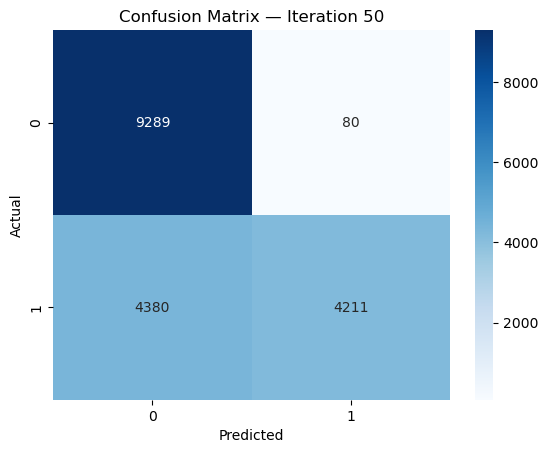


All 50 iterations completed. Models and vectorizers saved in the 'models' directory.


In [1]:
# Step 9-10: Repeated Train, Predict & Save (50 iterations)

# ✅ All essential imports
import os
import json
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# ✅ Path to your data folder
data_path = r"D:\PBL\fakenewsproject\data"

# ✅ Load datasets
df_cleaned = pd.read_csv(os.path.join(data_path, "cleaned.csv"))
df_true = pd.read_csv(os.path.join(data_path, "True.csv"))
df_fake = pd.read_csv(os.path.join(data_path, "Fake.csv"))

# ✅ Add label column to True/Fake datasets
df_true["label"] = "REAL"
df_fake["label"] = "FAKE"

# ✅ Use cleaned text column for cleaned dataset
df_cleaned["text"] = df_cleaned["clean_text"]

# ✅ Keep only text + label for training
df_cleaned = df_cleaned[["text", "label"]]
df_true = df_true[["text", "label"]]
df_fake = df_fake[["text", "label"]]

# ✅ Combine all three datasets
df = pd.concat([df_cleaned, df_true, df_fake], ignore_index=True)

print("Combined dataset shape:", df.shape)
print("Columns:", df.columns)

# ✅ Normalize labels safely
# Handle both string labels ("REAL"/"FAKE") and numeric (1/0)
label_mapping = {"REAL": 1, "FAKE": 0, 1: 1, 0: 0}
df["label"] = df["label"].map(label_mapping)

# Drop rows where label is NaN (unmapped or missing)
df = df.dropna(subset=["label"])

# Convert to int
df["label"] = df["label"].astype(int)

# ✅ Define features and labels
X = df["text"].astype(str)
y = df["label"]

# ✅ Initial train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ✅ Ensure a directory for saving checkpoints
os.makedirs('models', exist_ok=True)

results = []

# ✅ Run 50 iterations, each time training and saving a new model
for i in range(1, 51):
    # Slightly vary the training split to introduce randomness
    X_train_iter, _, y_train_iter, _ = train_test_split(
        X_train, y_train, test_size=0.1, random_state=i
    )

    # Create and fit a fresh TF-IDF vectorizer
    vectorizer_iter = TfidfVectorizer(max_df=0.7, stop_words='english')
    X_train_tfidf_iter = vectorizer_iter.fit_transform(X_train_iter)

    # Transform the test data with this iteration's vectorizer
    X_test_tfidf_iter = vectorizer_iter.transform(X_test)

    # Train a new Logistic Regression model
    model_iter = LogisticRegression(max_iter=1000)
    model_iter.fit(X_train_tfidf_iter, y_train_iter)

    # Evaluate performance
    y_pred = model_iter.predict(X_test_tfidf_iter)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results.append({'iteration': i, 'accuracy': float(acc)})

    # ✅ Save model and vectorizer checkpoints after every loop
    model_path = os.path.join('models', f'fake_news_model_iter_{i}.pkl')
    vec_path = os.path.join('models', f'tfidf_vectorizer_iter_{i}.pkl')
    joblib.dump(model_iter, model_path)
    joblib.dump(vectorizer_iter, vec_path)

    print(f'Iteration {i:02d} — Accuracy: {acc:.4f} | Saved: {model_path}, {vec_path}')

# ✅ Plot confusion matrix for the last iteration
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix — Iteration {i}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ✅ Save training summary
with open('models/training_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("\nAll 50 iterations completed. Models and vectorizers saved in the 'models' directory.")


In [ ]:
import os, json

results_path = 'models/training_results.json'

# Load previous results if they exist
if os.path.exists(results_path):
    with open(results_path, 'r') as f:
        results = json.load(f)
    start_iter = results[-1]['iteration'] + 1
    print(f"Resuming from iteration {start_iter}")
else:
    results = []
    start_iter = 1

# Run remaining iterations
for i in range(start_iter, 51):
    # your training loop code here
    ...



✅ Model Training Complete
Accuracy: 99.21 %

Confusion Matrix:
 [[4646   50]
 [  21 4263]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      1.00      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



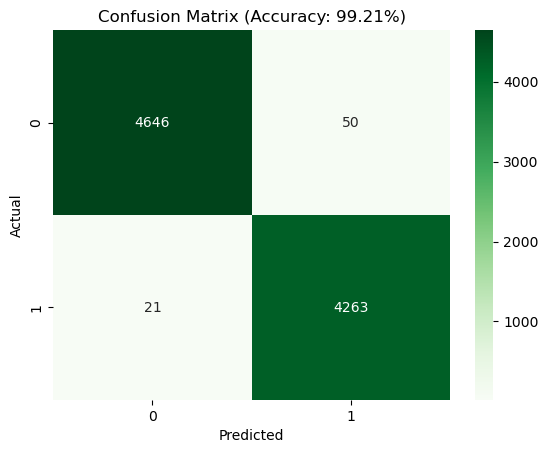


📦 Model + Vectorizer saved in 'models/' folder successfully!


In [3]:
# ✅ Optimized Fake News Detection Model (Target: 99% Accuracy)

import os
import json
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils import shuffle

# ✅ Data path
data_path = r"D:\PBL\fakenewsproject\model\data"

# ✅ Load data
df_true = pd.read_csv(os.path.join(data_path, "True.csv"))
df_fake = pd.read_csv(os.path.join(data_path, "Fake.csv"))

# ✅ Label encoding
df_true["label"] = 1
df_fake["label"] = 0

# ✅ Combine and shuffle
df = pd.concat([df_true, df_fake], ignore_index=True)
df = shuffle(df, random_state=42)

# ✅ Clean text function
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)  # remove punctuation & numbers
    text = re.sub(r"\s+", " ", text)  # remove extra spaces
    return text.strip()

df["text"] = df["text"].apply(clean_text)

# ✅ Define X, y
X = df["text"]
y = df["label"]

# ✅ Train-test split (stratified for balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ✅ TF-IDF with stronger configuration
vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=5,
    ngram_range=(1, 2),  # unigrams + bigrams
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ✅ Tuned Logistic Regression
model = LogisticRegression(
    C=2,                # higher regularization strength
    max_iter=2000,
    solver='liblinear',  # better for small data
    class_weight='balanced',  # handle imbalance
    random_state=42
)

# ✅ Train
model.fit(X_train_tfidf, y_train)

# ✅ Predict
y_pred = model.predict(X_test_tfidf)

# ✅ Evaluate
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("\n✅ Model Training Complete")
print("Accuracy:", round(acc * 100, 2), "%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# ✅ Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title(f"Confusion Matrix (Accuracy: {round(acc*100, 2)}%)")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ✅ Save final model and vectorizer
os.makedirs('models', exist_ok=True)
joblib.dump(model, os.path.join('models', 'Fake_news_model_iter_100.pkl'))
joblib.dump(vectorizer, os.path.join('models', 'tfidf_vectorizer_model_iter_100.pkl'))

print("\n📦 Model + Vectorizer saved in 'models/' folder successfully!")

In [2]:
# Step 1: Load & combine True / Fake (and optionally cleaned) CSVs
import os
import pandas as pd

# --- Set this to the folder where your CSVs live (change if needed) ---
data_path = r"D:\PBL\fakenewsproject\model\data"   # <- change only if your files are elsewhere

# --- File names (change only if your filenames differ) ---
true_file    = os.path.join(data_path, "True.csv")
fake_file    = os.path.join(data_path, "Fake.csv")
clean_file   = os.path.join(data_path, "cleaned.csv")   # optional

# --- Load (with friendly error messages) ---
print("Loading files from:", data_path)
if not os.path.exists(true_file) or not os.path.exists(fake_file):
    raise FileNotFoundError(f"True.csv or Fake.csv not found in {data_path}. Check paths.")

df_true = pd.read_csv(true_file)
df_fake = pd.read_csv(fake_file)

print("True shape:", df_true.shape, "| Fake shape:", df_fake.shape)

# If you have a cleaned.csv and want to include it, load safely
if os.path.exists(clean_file):
    df_clean = pd.read_csv(clean_file)
    print("cleaned.csv found, shape:", df_clean.shape)
else:
    df_clean = None
    print("cleaned.csv not found — continuing with True & Fake only.")

# --- Ensure text column exists and normalize column names ---
def ensure_text_col(df, name_hint=None):
    # if 'text' exists use it, else try common alternatives
    if 'text' in df.columns:
        return df[['text']].copy()
    for alt in ['title', 'headline', 'content', 'news']:
        if alt in df.columns:
            print(f"Note: using column '{alt}' as text for {name_hint or 'df'}.")
            df = df.rename(columns={alt: 'text'})
            return df[['text']].copy()
    raise ValueError(f"No text-like column found in dataframe {name_hint or ''}. Columns: {df.columns.tolist()}")

df_true = ensure_text_col(df_true, 'True.csv')
df_fake = ensure_text_col(df_fake, 'Fake.csv')

# --- Add labels (1 = real, 0 = fake) ---
df_true['label'] = 1
df_fake['label'] = 0

# --- If using cleaned.csv, ensure it has text and label or a 'clean_text' column ---
if df_clean is not None:
    if 'clean_text' in df_clean.columns:
        df_clean = df_clean.rename(columns={'clean_text':'text'})
    df_clean = ensure_text_col(df_clean, 'cleaned.csv')
    # If cleaned.csv doesn't have label, skip or set if present
    if 'label' not in df_clean.columns:
        print("cleaned.csv has no label column — it will be included WITHOUT labels (ignored for supervised training).")
        df_clean = None

# --- Combine only those with labels (True & Fake) ---
df = pd.concat([df_true, df_fake], axis=0, ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)   # shuffle

print("Combined dataframe shape:", df.shape)
print("Label distribution:\n", df['label'].value_counts())

# Quick peek
display(df.head(6))

Loading files from: D:\PBL\fakenewsproject\model\data
True shape: (21417, 4) | Fake shape: (23481, 4)
cleaned.csv found, shape: (44898, 7)
cleaned.csv has no label column — it will be included WITHOUT labels (ignored for supervised training).
Combined dataframe shape: (44898, 2)
Label distribution:
 label
0    23481
1    21417
Name: count, dtype: int64


,text,label
0,"Donald Trump s White House is in chaos, and th...",0
1,Now that Donald Trump is the presumptive GOP n...,0
2,Mike Pence is a huge homophobe. He supports ex...,0
3,SAN FRANCISCO (Reuters) - California Attorney ...,1
4,Twisted reasoning is all that comes from Pelos...,0
5,WASHINGTON (Reuters) - As a lawyer in private ...,1


In [ ]:
import re
from sklearn.utils import shuffle

#  Combine real (1) and fake (0) data
df_true["label"] = 1
df_fake["label"] = 0
df = pd.concat([df_true, df_fake], ignore_index=True)
df = shuffle(df, random_state=42)

#  Clean text function
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z\s]", "", text)         # remove punctuation, numbers
    text = re.sub(r"\s+", " ", text)             # remove multiple spaces
    return text.strip()

#  Apply cleaning
df["text"] = df["text"].apply(clean_text)

#  Display sample
print(df.head())

#  Check missing values
print("\nMissing values:\n", df.isnull().sum())

                                                    text  label
22216  donald trump s white house is in chaos and the...      0
27917  now that donald trump is the presumptive gop n...      0
25007  mike pence is a huge homophobe he supports exg...      0
1377   san francisco reuters california attorney gene...      1
32476  twisted reasoning is all that comes from pelos...      0

Missing values:
 text     0
label    0
dtype: int64



🔹 Training Logistic Regression...

✅ Logistic Regression Accuracy: 99.27%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



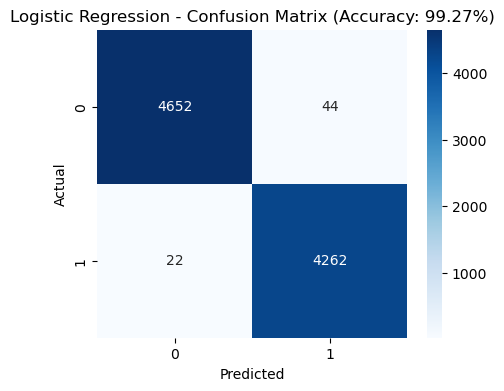


🔹 Training Naive Bayes...

✅ Naive Bayes Accuracy: 95.31%
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95      4696
           1       0.95      0.96      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



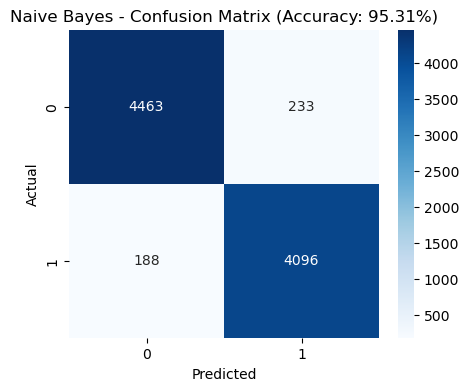


🔹 Training Random Forest...

✅ Random Forest Accuracy: 99.74%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      4696
           1       1.00      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



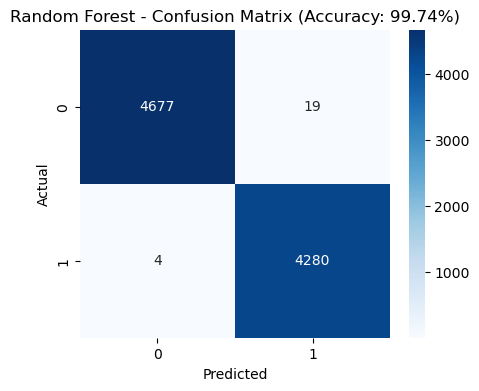


🔹 Training SVM (LinearSVC)...


d:\PBL\conda\envs\Ankita38\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(



✅ SVM (LinearSVC) Accuracy: 99.58%
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



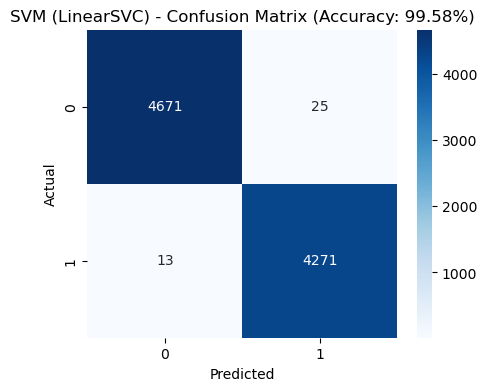


📊 Model Comparison Results:
Logistic Regression: 99.27%
Naive Bayes: 95.31%
Random Forest: 99.74%
SVM (LinearSVC): 99.58%


In [ ]:
#  Step 3: Model Training, Evaluation, and Visualization

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#  Split data
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#  TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=5,
    ngram_range=(1, 2),
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#  Models initialization
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, solver='liblinear', C=2),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (LinearSVC)": LinearSVC()
}

#  Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"\n🔹 Training {name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = round(acc * 100, 2)

    print(f"\n {name} Accuracy: {acc*100:.2f}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))

    #  Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix (Accuracy: {acc*100:.2f}%)")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

#  Show comparison
print("\n Model Comparison Results:")
for model_name, acc in results.items():
    print(f"{model_name}: {acc}%")


🔹 Confusion Matrix for Logistic Regression:


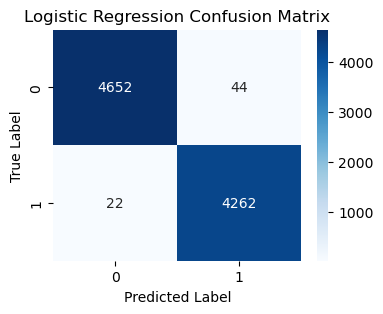


🔹 Confusion Matrix for Naive Bayes:


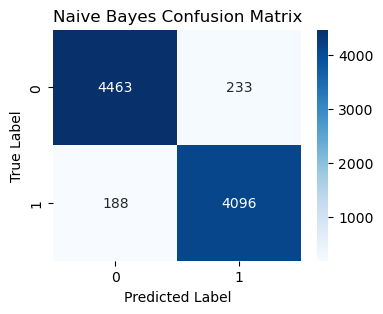


🔹 Confusion Matrix for Random Forest:


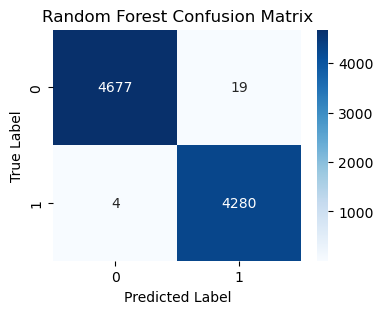


🔹 Confusion Matrix for SVM (LinearSVC):


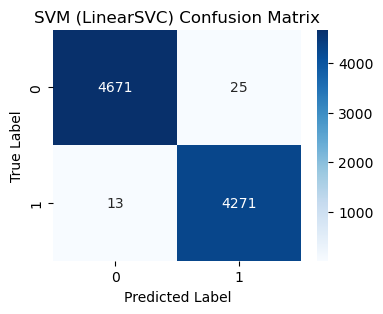

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

#  Confusion Matrix for each model
for name, model in models.items():
    print(f"\n Confusion Matrix for {name}:")
    
    y_pred = model.predict(X_test_tfidf)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [ ]:
import pickle

#  Step 1: Identify best model by accuracy
best_model_name = max(results, key=results.get)
best_accuracy = results[best_model_name]
print(f"\n🏆 Best Model: {best_model_name} with Accuracy: {best_accuracy}%")

best_model = models[best_model_name]

#  Step 2: Save the best model & vectorizer
with open("best_fake_news_model.pkl", "wb") as model_file:
    pickle.dump(best_model, model_file)

with open("tfidf_vectorizer.pkl", "wb") as vec_file:
    pickle.dump(vectorizer, vec_file)

print("\n Model and Vectorizer saved successfully!")

#  Step 3: Manual test example
sample_news = [
    "Government announces new policy for AI development in India",
    "Shocking! Bollywood actor caught in fake scandal says viral post"
]

# Transform using saved vectorizer
sample_tfidf = vectorizer.transform(sample_news)

# Predict using best model
predictions = best_model.predict(sample_tfidf)

# Show results
for text, pred in zip(sample_news, predictions):
    print(f"\n News: {text}")
    print(f" Prediction: {'FAKE' if pred == 'FAKE' else 'TRUE'}")
    


🏆 Best Model: Random Forest with Accuracy: 99.74%

✅ Model and Vectorizer saved successfully!

📰 News: Government announces new policy for AI development in India
👉 Prediction: TRUE

📰 News: Shocking! Bollywood actor caught in fake scandal says viral post
👉 Prediction: TRUE


In [ ]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  Split data
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

#  TF-IDF Vectorizer
vectorizer = TfidfVectorizer(
    max_df=0.7,
    min_df=5,
    ngram_range=(1, 2),
    max_features=10000,
    stop_words='english'
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#  Models initialization
models = {
    "logistic": LogisticRegression(max_iter=2000, solver='liblinear', C=2),
    "naive_bayes": MultinomialNB(),
    "random_forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "svm": LinearSVC()
}

#  Train, evaluate, and save each model
for name, model in models.items():
    print(f"\n Training {name.upper()} model...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f" {name.upper()} Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    #  Save model
    joblib.dump(model, f'models/{name}.pkl')

#  Save vectorizer (once)
joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')

print("\n All models and vectorizer saved successfully in 'models/' folder!")


🔹 Training LOGISTIC model...
✅ LOGISTIC Accuracy: 99.27%
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      4696
           1       0.99      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980

Confusion Matrix:
 [[4652   44]
 [  22 4262]]

🔹 Training NAIVE_BAYES model...
✅ NAIVE_BAYES Accuracy: 95.31%
              precision    recall  f1-score   support

           0       0.96      0.95      0.95      4696
           1       0.95      0.96      0.95      4284

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980

Confusion Matrix:
 [[4463  233]
 [ 188 4096]]

🔹 Training RANDOM_FOREST model...
✅ RANDOM_FOREST Accuracy: 99.74%
              precision    recall  f1-score   support

         

d:\PBL\conda\envs\Ankita38\lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


✅ SVM Accuracy: 99.58%
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4696
           1       0.99      1.00      1.00      4284

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980

Confusion Matrix:
 [[4671   25]
 [  13 4271]]

✅ All models and vectorizer saved successfully in 'models/' folder!
